Imports, podem alterar conforme necessário

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split

#### Lendo base de dados e removendo valores aleatoriamente **executar SEM ALTERAR**

In [2]:
#Carregando base de dados
penguins = sns.load_dataset('penguins')

np.random.seed(42)  #Definindo seed do random para replicabilidade

#Removendo valores
removidos = set()
porcentagem = 0.30 #Porcentagem (0~1) das células a serem removidas
qtdCelulas = len(penguins)*(len(penguins.columns)) #Quantidade de células na base de dados, ignorando a última coluna

for i in range(int(np.ceil(porcentagem*qtdCelulas))):
  linha = np.random.randint(0, len(penguins))
  coluna = np.random.randint(0, len(penguins.columns))
  while (linha, coluna) in removidos:
    linha = np.random.randint(0, len(penguins))
    coluna = np.random.randint(0, len(penguins.columns))

  penguins.iloc[linha, coluna] = np.nan
  removidos.add((linha,coluna))

penguins.info()
print("\n\nForam removidas ",str(len(removidos)), "células das ",str(qtdCelulas))
del removidos
del qtdCelulas
del porcentagem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            232 non-null    object 
 1   island             241 non-null    object 
 2   bill_length_mm     233 non-null    float64
 3   bill_depth_mm      244 non-null    float64
 4   flipper_length_mm  247 non-null    float64
 5   body_mass_g        240 non-null    float64
 6   sex                235 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Foram removidas  723 células das  2408


# **Podem modificar daqui para baixo para fazer a imputação de valores**

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,NaN,18.7,NaN,3750.0,Male
1,NaN,NaN,39.5,17.4,186.0,NaN,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,NaN,NaN,19.3,193.0,3450.0,NaN
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,NaN,46.8,14.3,215.0,NaN,NaN
341,NaN,Biscoe,NaN,NaN,NaN,5750.0,NaN
342,Gentoo,Biscoe,45.2,14.8,NaN,5200.0,Female


## Transformando o Dataset penguins (com NaN) para CSV

In [4]:
penguins.to_csv("penguins_inicial.csv", index=False, na_rep="?")

## Removendo Linhas de Baixa Qualidade

Linhas com 2 ou menos atributos válidos não têm informação suficiente para que qualquer
técnica de imputação produza resultados confiáveis. Removê-las antes de qualquer
imputação evita que ruído entre no treinamento dos modelos KNN.

In [5]:
linhasBaixaQualidade = penguins[penguins.notna().sum(axis=1) <= 2].index.tolist()

display(penguins.loc[linhasBaixaQualidade])

penguins = penguins.drop(linhasBaixaQualidade, axis=0)

display(penguins.isna().sum())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,Dream,NaN,19.3,NaN,NaN,NaN
50,NaN,Biscoe,NaN,NaN,NaN,NaN,Female
228,NaN,NaN,NaN,NaN,209.0,NaN,Female
230,NaN,NaN,NaN,13.7,NaN,NaN,Female
263,NaN,NaN,NaN,15.0,NaN,4750.0,NaN
292,NaN,Biscoe,NaN,15.6,NaN,NaN,NaN
302,NaN,NaN,47.4,NaN,NaN,4725.0,NaN
317,NaN,Biscoe,NaN,NaN,NaN,NaN,Female
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


,0
species,103
island,98
bill_length_mm,101
bill_depth_mm,93
flipper_length_mm,87
body_mass_g,96
sex,102


## Análise Exploratória dos Dados

Antes de imputar, analisamos a distribuição dos atributos por espécie e ilha para entender
quais limiares separam as espécies e quais atributos são mais informativos para o KNN.

In [6]:
display(penguins.isna().sum())
display(penguins.island.value_counts())

,0
species,103
island,98
bill_length_mm,101
bill_depth_mm,93
flipper_length_mm,87
body_mass_g,96
sex,102


,count
island,
Biscoe,119
Dream,85
Torgersen,31


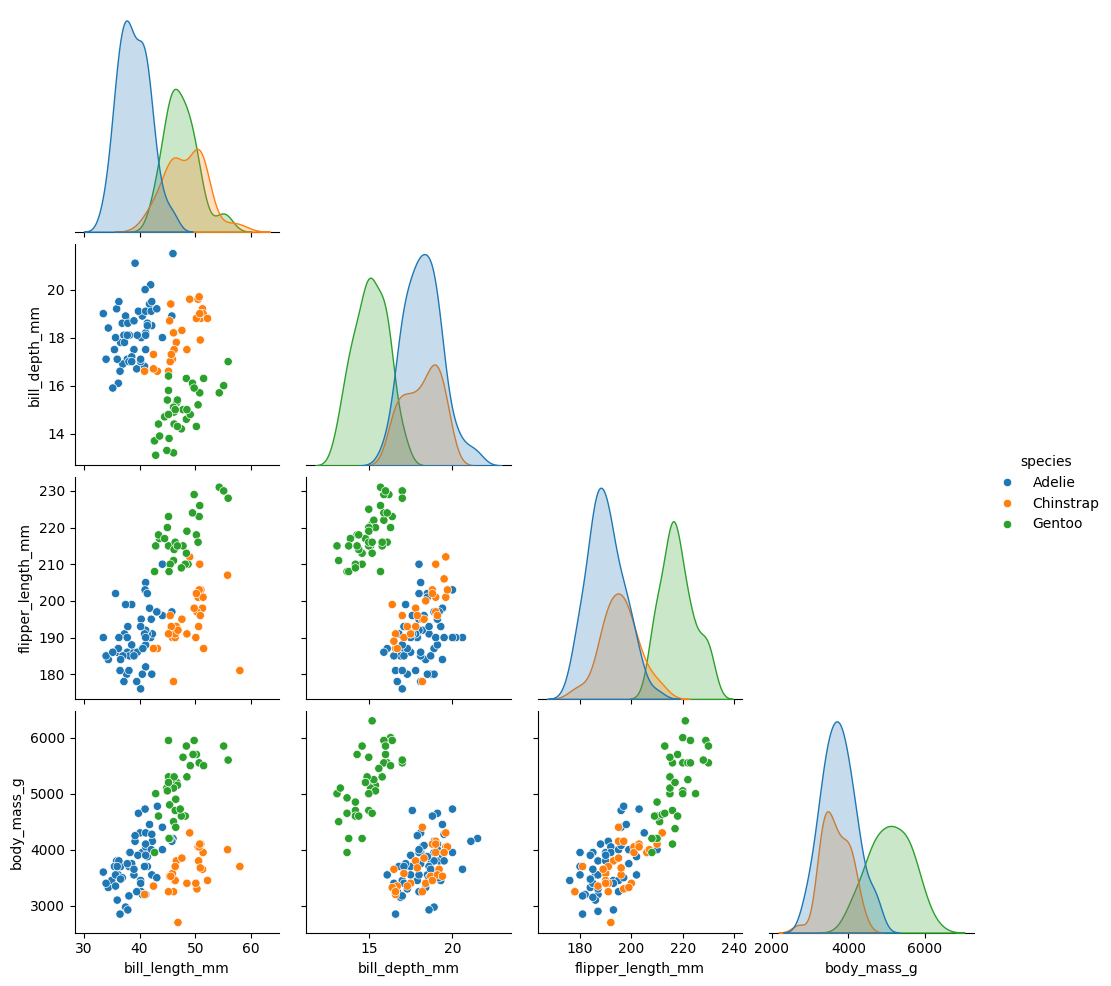

In [7]:
sns.pairplot(penguins, corner=True, hue="species")
plt.show()

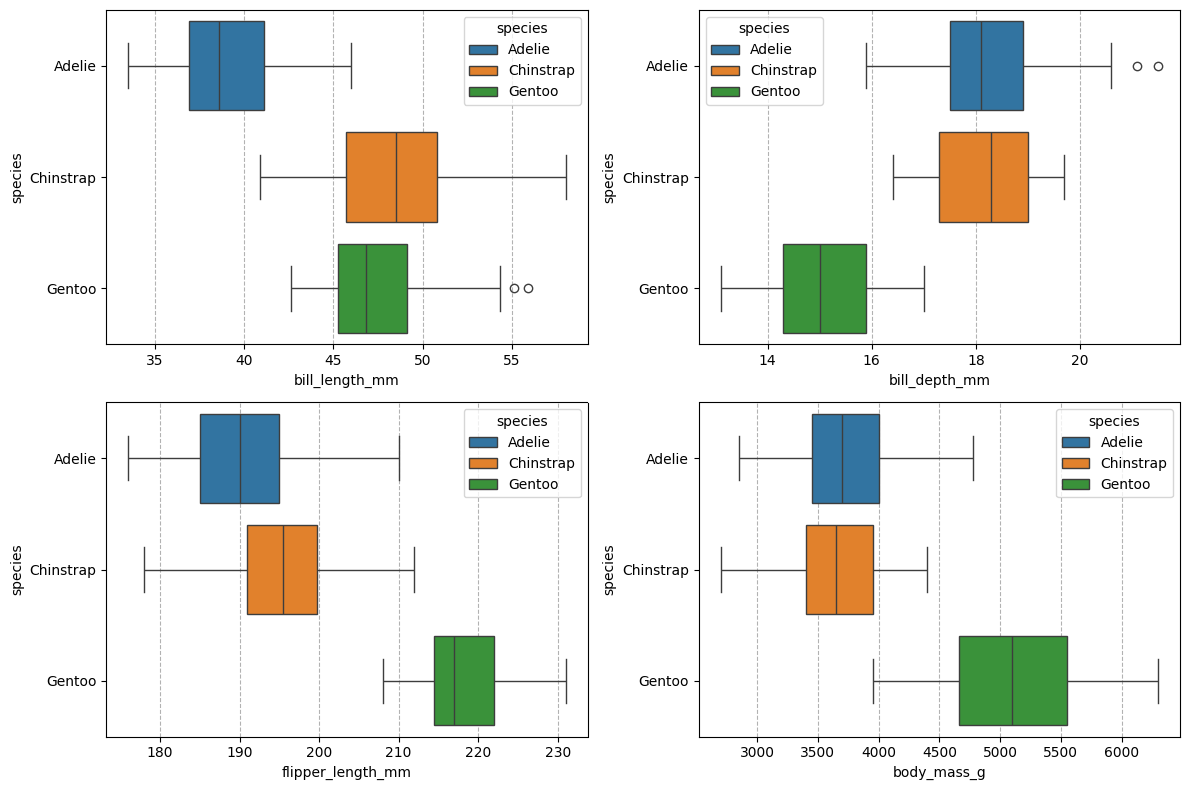

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(penguins, x="bill_length_mm", y="species", hue="species", ax=axes[0, 0])
axes[0, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="bill_depth_mm", y="species", hue="species", ax=axes[0, 1])
axes[0, 1].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="flipper_length_mm", y="species", hue="species", ax=axes[1, 0])
axes[1, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="body_mass_g", y="species", hue="species", ax=axes[1, 1])
axes[1, 1].grid(axis='x', linestyle="--", alpha=0.3, color="Black")

plt.tight_layout()
plt.show()

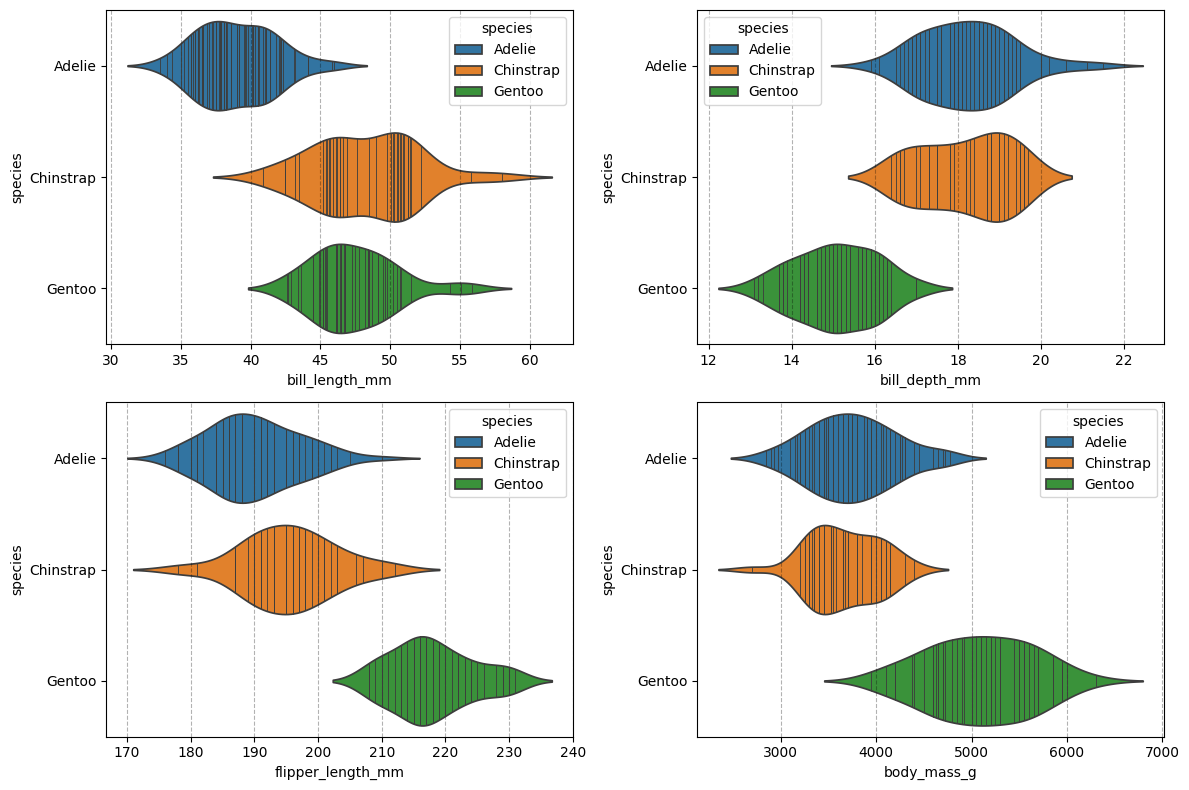

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(penguins, x="bill_length_mm", y="species", hue="species", inner='stick', ax=axes[0, 0])
axes[0, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="bill_depth_mm", y="species", hue="species", inner='stick', ax=axes[0, 1])
axes[0, 1].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="flipper_length_mm", y="species", hue="species", inner='stick', ax=axes[1, 0])
axes[1, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="body_mass_g", y="species", hue="species", inner='stick', ax=axes[1, 1])
axes[1, 1].grid(axis='x', linestyle="--", alpha=0.3, color="Black")

plt.tight_layout()
plt.show()

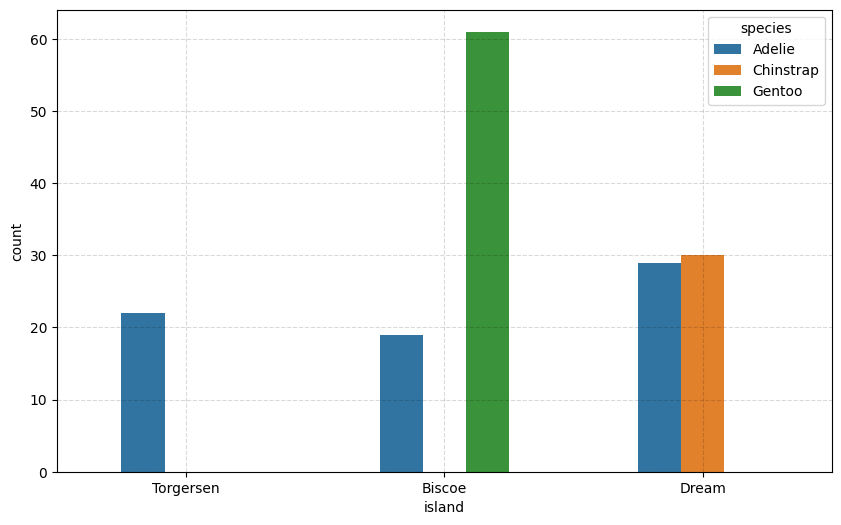

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(penguins, x="island", hue="species", width=0.5)
plt.grid(linestyle="--", color="Black", alpha=0.15)
plt.show()

In [11]:
print("Adelie")
display(penguins[penguins["species"] == "Adelie"].describe())
print("\nChinstrap")
display(penguins[penguins["species"] == "Chinstrap"].describe())
print("\nGentoo")
display(penguins[penguins["species"] == "Gentoo"].describe())

Adelie


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,73.000000,73.000000,74.000000,78.000000
mean,38.995890,18.235616,189.972973,3748.717949
std,2.743752,1.119818,7.012656,446.139600
min,33.500000,15.900000,176.000000,2850.000000
25%,36.900000,17.500000,185.000000,3450.000000
50%,38.600000,18.100000,190.000000,3700.000000
75%,41.100000,18.900000,195.000000,4000.000000
max,46.000000,21.500000,210.000000,4775.000000



Chinstrap


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,37.000000,35.000000,38.000000,38.000000
mean,48.270270,18.174286,195.473684,3665.131579
std,3.695934,1.057840,7.269845,365.928081
min,40.900000,16.400000,178.000000,2700.000000
25%,45.700000,17.300000,191.000000,3400.000000
50%,48.500000,18.300000,195.500000,3650.000000
75%,50.800000,19.000000,199.750000,3950.000000
max,58.000000,19.700000,212.000000,4400.000000



Gentoo


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,48.000000,61.000000,55.000000,54.000000
mean,47.458333,15.088525,217.963636,5095.370370
std,3.009547,0.980323,6.347830,548.692143
min,42.600000,13.100000,208.000000,3950.000000
25%,45.275000,14.300000,214.500000,4662.500000
50%,46.800000,15.000000,217.000000,5100.000000
75%,49.100000,15.900000,222.000000,5550.000000
max,55.900000,17.000000,231.000000,6300.000000


Gentoo — Biscoe


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,36.000000,45.000000,38.000000,41.000000
mean,47.344444,15.044444,217.552632,5129.268293
std,2.782953,0.953357,5.971542,551.500862
min,42.600000,13.100000,208.000000,4100.000000
25%,45.350000,14.300000,214.250000,4700.000000
50%,46.750000,15.000000,216.500000,5100.000000
75%,48.500000,15.800000,220.000000,5550.000000
max,55.100000,17.000000,231.000000,6300.000000



Adelie — Biscoe


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,15.000000,13.000000,15.000000,16.000000
mean,39.573333,18.323077,189.000000,3796.875000
std,1.941820,0.812562,6.082763,532.437399
min,36.500000,16.600000,180.000000,2850.000000
25%,38.050000,18.100000,185.500000,3662.500000
50%,39.000000,18.600000,188.000000,3875.000000
75%,41.100000,18.900000,193.000000,4081.250000
max,43.200000,19.500000,199.000000,4775.000000


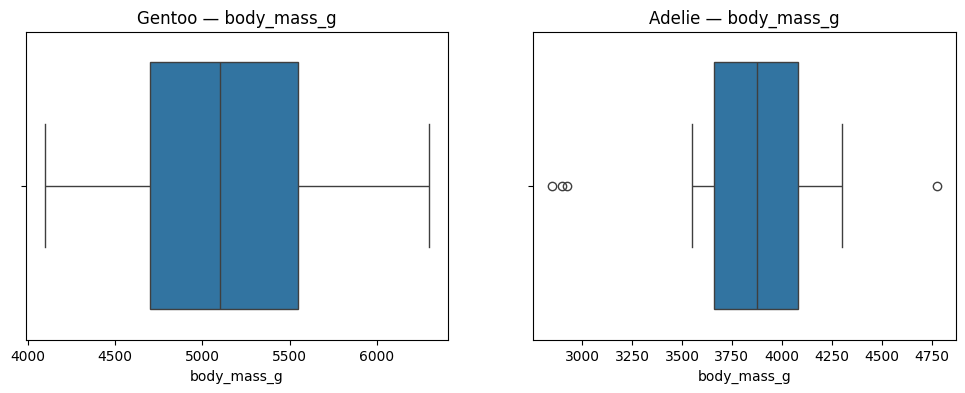

In [12]:
penguinsBiscoe_desc = penguins[penguins.island == "Biscoe"].copy()

print("Gentoo — Biscoe")
display(penguinsBiscoe_desc[penguinsBiscoe_desc.species == "Gentoo"].describe())
print("\nAdelie — Biscoe")
display(penguinsBiscoe_desc[penguinsBiscoe_desc.species == "Adelie"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(penguinsBiscoe_desc[penguinsBiscoe_desc.species == "Gentoo"], x="body_mass_g", ax=axes[0])
axes[0].set_title("Gentoo — body_mass_g")
sns.boxplot(penguinsBiscoe_desc[penguinsBiscoe_desc.species == "Adelie"], x="body_mass_g", ax=axes[1])
axes[1].set_title("Adelie — body_mass_g")
plt.show()

## 1. Imputação de Espécie

A espécie é o atributo mais importante: cada espécie tem perfil físico distinto e todas as
imputações seguintes dependem dela. Usamos limiares de massa, nadadeira
e bico observados na análise para classificar os pinguins com espécie ausente.

### Ilha Biscoe

Na Biscoe convivem Adelie e Gentoo. Os Gentoo são muito maiores e possuem bicos mais longos com profundidade menor.
Adelie ficam abaixo dos limiares opostos.

In [13]:
penguinsBiscoe = penguins[penguins.island == "Biscoe"].copy()

penguinsBiscoe_bm_g4300 = penguinsBiscoe[penguinsBiscoe.body_mass_g > 4300].copy()
penguinsBiscoe_bm_g4300["species"].fillna("Gentoo", inplace=True)
penguins.update(penguinsBiscoe_bm_g4300)

penguinsBiscoe_bm_l4100 = penguinsBiscoe[penguinsBiscoe.body_mass_g < 4100].copy()
penguinsBiscoe_bm_l4100["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsBiscoe_bm_l4100)

penguinsBiscoe_fl_g214 = penguinsBiscoe[penguinsBiscoe.flipper_length_mm >= 214.5].copy()
penguinsBiscoe_fl_g214["species"].fillna("Gentoo", inplace=True)
penguins.update(penguinsBiscoe_fl_g214)

penguinsBiscoe_fl_m199 = penguinsBiscoe[penguinsBiscoe.flipper_length_mm <= 199].copy()
penguinsBiscoe_fl_m199["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsBiscoe_fl_m199)

penguinsBiscoe_fl_g208 = penguinsBiscoe[penguinsBiscoe.flipper_length_mm >= 208].copy()
penguinsBiscoe_fl_g208["species"].fillna("Gentoo", inplace=True)
penguins.update(penguinsBiscoe_fl_g208)

penguinsBiscoe_bd_l16 = penguinsBiscoe[penguinsBiscoe.bill_depth_mm < 16].copy()
penguinsBiscoe_bd_l16["species"].fillna("Gentoo", inplace=True)
penguins.update(penguinsBiscoe_bd_l16)

penguinsBiscoe_bl_g42 = penguinsBiscoe[penguinsBiscoe.bill_length_mm > 42.2].copy()
penguinsBiscoe_bl_g42["species"].fillna("Gentoo", inplace=True)
penguins.update(penguinsBiscoe_bl_g42)

penguinsBiscoe_bl_l42 = penguinsBiscoe[penguinsBiscoe.bill_length_mm < 42.6].copy()
penguinsBiscoe_bl_l42["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsBiscoe_bl_l42)

display(penguins[penguins.island == "Biscoe"].isna().sum())
display(penguins[(penguins.island == "Biscoe") & (penguins.species.isna())])

/tmp/ipykernel_2091/3335509993.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguinsBiscoe_bm_g4300["species"].fillna("Gentoo", inplace=True)
/tmp/ipykernel_2091/3335509993.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,0
species,1
island,0
bill_length_mm,37
bill_depth_mm,37
flipper_length_mm,40
body_mass_g,36
sex,35


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
62,NaN,Biscoe,NaN,17.0,NaN,NaN,Female


Os 3 pinguins da Biscoe cujas medidas ficam na zona de sobreposição entre Adelie e Gentoo
são removidos: não é possível determinar a espécie com confiança e imputar no achismo
introduziria erro no dataset.

In [14]:
penguins = penguins.drop(62, axis=0)

display(penguins[penguins.island == "Biscoe"].isna().sum())

,0
species,0
island,0
bill_length_mm,36
bill_depth_mm,37
flipper_length_mm,39
body_mass_g,35
sex,35


### Ilha Torgersen

Na ilha Torgersen vivem exclusivamente Adelie. Todos os valores ausentes de espécie
nessa ilha são imputados diretamente como Adelie.

In [15]:
penguinsTorgersen = penguins[penguins["island"] == "Torgersen"].copy()
penguinsTorgersen["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsTorgersen)

display(penguins[penguins.island == "Torgersen"].isna().sum())

/tmp/ipykernel_2091/4278306414.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguinsTorgersen["species"].fillna("Adelie", inplace=True)


,0
species,0
island,0
bill_length_mm,8
bill_depth_mm,6
flipper_length_mm,8
body_mass_g,6
sex,6


### Ilha Dream

Na ilha Dream convivem Adelie e Chinstrap. Os Chinstrap têm bico mais longo
e nadadeira maior. Usamos massa corporal, comprimento de bico e nadadeira
para separar as duas espécies.

In [16]:
penguinsDream = penguins[penguins.island == "Dream"].copy()

penguinsDream_bm_l3200 = penguinsDream[penguinsDream.body_mass_g < 3200].copy()
penguinsDream_bm_l3200["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsDream_bm_l3200)

penguinsDream_bl_l40 = penguinsDream[penguinsDream.bill_length_mm < 40.9].copy()
penguinsDream_bl_l40["species"].fillna("Adelie", inplace=True)
penguins.update(penguinsDream_bl_l40)

penguinsDream_bl_g44 = penguinsDream[penguinsDream.bill_length_mm > 44.1].copy()
penguinsDream_bl_g44["species"].fillna("Chinstrap", inplace=True)
penguins.update(penguinsDream_bl_g44)

penguinsDream_fl_g201 = penguinsDream[penguinsDream.flipper_length_mm > 201].copy()
penguinsDream_fl_g201["species"].fillna("Chinstrap", inplace=True)
penguins.update(penguinsDream_fl_g201)

display(penguins[penguins.island == "Dream"].isna().sum())
display(penguins[(penguins.island == "Dream") & (penguins.species.isna())])

/tmp/ipykernel_2091/3888757789.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguinsDream_bm_l3200["species"].fillna("Adelie", inplace=True)
/tmp/ipykernel_2091/3888757789.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,0
species,9
island,0
bill_length_mm,28
bill_depth_mm,24
flipper_length_mm,23
body_mass_g,26
sex,32


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
33,NaN,Dream,40.9,18.9,184.0,NaN,NaN
46,NaN,Dream,NaN,19.0,182.0,3425.0,Male
99,NaN,Dream,NaN,18.5,192.0,4100.0,Male
132,NaN,Dream,NaN,18.5,193.0,NaN,Female
134,NaN,Dream,NaN,17.6,187.0,3425.0,Female
148,NaN,Dream,NaN,17.8,195.0,NaN,NaN
186,NaN,Dream,NaN,18.6,195.0,NaN,NaN
197,NaN,Dream,NaN,18.5,201.0,NaN,NaN
214,NaN,Dream,NaN,NaN,NaN,3650.0,Female


### Nadadeira ≥ 214.5mm → Gentoo (qualquer ilha)

Nadadeira acima de 214.5mm é exclusivo de Gentoo em todo o dataset. Essa regra cobre
pinguins com ilha ausente mas que são claramente Gentoo pelas medidas físicas.

In [17]:
penguins_fl_g214 = penguins[penguins.flipper_length_mm >= 214.5].copy()
penguins_fl_g214["species"].fillna("Gentoo", inplace=True)
penguins.update(penguins_fl_g214)

display(penguins.isna().sum())

/tmp/ipykernel_2091/973078058.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_fl_g214["species"].fillna("Gentoo", inplace=True)


,0
species,32
island,98
bill_length_mm,100
bill_depth_mm,93
flipper_length_mm,86
body_mass_g,95
sex,102


### Espécie — KNN Fallback

Algumas linhas ainda têm espécie desconhecida — são os casos
onde as medidas físicas ficaram na zona de sobreposição entre espécies ou onde a ilha
também era desconhecida. Usamos KNN Classifier com os atributos físicos disponíveis
para classificar esses casos restantes.

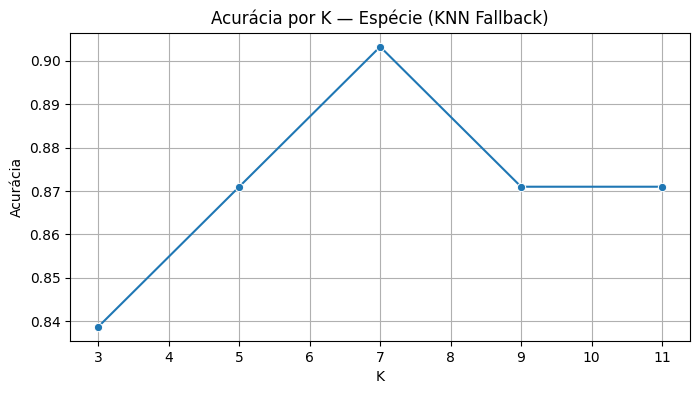

Melhor K: 7 | Acurácia: 0.903


,0
species,0
island,98
bill_length_mm,100
bill_depth_mm,93
flipper_length_mm,86
body_mass_g,95
sex,102


In [18]:
treino_sp = penguins[penguins["species"].notna()]
prever_sp  = penguins[penguins["species"].isna()].copy()

cols_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

X_train = treino_sp[cols_features]
y_train = treino_sp["species"]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="nan_euclidean")
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k] = knn.score(X_val_limpo, y_val_limpo)

acertosX = list(acertos.keys())
acertosY = list(acertos.values())

plt.figure(figsize=(8, 4))
sns.lineplot(x=acertosX, y=acertosY, marker="o")
plt.title("Acurácia por K — Espécie (KNN Fallback)")
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | Acurácia: {acertos[melhor_k]:.3f}")

knn_sp = KNeighborsClassifier(n_neighbors=melhor_k, metric="nan_euclidean")
knn_sp.fit(X_train, y_train)

prever_sp["species"] = knn_sp.predict(prever_sp[cols_features])
penguins.update(prever_sp)

display(penguins.isna().sum())

## 2. Imputação de Ilha

Com as espécies imputadas, podemos determinar a ilha dos Gentoo e Chinstrap de forma
determinística: todo Gentoo é da Biscoe e todo Chinstrap é da Dream.

In [19]:
penguinsGentoo = penguins[penguins["species"] == "Gentoo"].copy()
penguinsGentoo["island"].fillna("Biscoe", inplace=True)
penguins.update(penguinsGentoo)

penguinsChinstrap = penguins[penguins["species"] == "Chinstrap"].copy()
penguinsChinstrap["island"].fillna("Dream", inplace=True)
penguins.update(penguinsChinstrap)

display(penguins.isna().sum())

/tmp/ipykernel_2091/2358065397.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguinsGentoo["island"].fillna("Biscoe", inplace=True)
/tmp/ipykernel_2091/2358065397.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
species,0
island,45
bill_length_mm,100
bill_depth_mm,93
flipper_length_mm,86
body_mass_g,95
sex,102


### Ilha dos Adelie — KNN Classifier

Os Adelie vivem nas três ilhas, portanto não é possível determinar a ilha de forma
determinística. Usamos KNN Classifier com os atributos físicos para estimar a ilha
de cada Adelie com ilha ausente. Testamos K de 3 a 11 e escolhemos o que maximiza a acurácia.

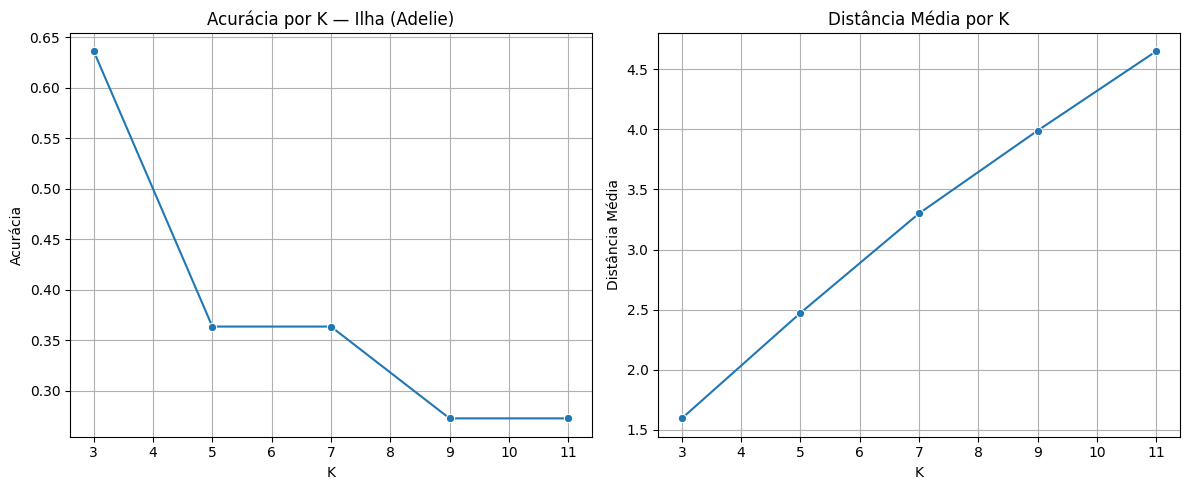

Melhor K: 3 | Acurácia: 0.636


,0
species,0
island,0
bill_length_mm,100
bill_depth_mm,93
flipper_length_mm,86
body_mass_g,95
sex,102


In [20]:
penguinsAdelie = penguins[penguins["species"] == "Adelie"].copy()

cols_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

treino_ilha = penguinsAdelie[penguinsAdelie["island"].notna()]
prever_ilha = penguinsAdelie[penguinsAdelie["island"].isna()].copy()

X_train = treino_ilha[cols_features]
y_train = treino_ilha["island"]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="nan_euclidean")
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker="o")
axes[0].set_title("Acurácia por K — Ilha (Adelie)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Acurácia")
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker="o")
axes[1].set_title("Distância Média por K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Distância Média")
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | Acurácia: {acertos[melhor_k]:.3f}")

knn_ilha = KNeighborsClassifier(n_neighbors=melhor_k, metric="nan_euclidean")
knn_ilha.fit(X_train, y_train)
prever_ilha["island"] = knn_ilha.predict(prever_ilha[cols_features])
penguins.update(prever_ilha)

display(penguins.isna().sum())

## 3. Imputação de Atributos Numéricos

Os atributos numéricos são imputados separadamente por espécie, pois as relações físicas
diferem entre Adelie, Chinstrap e Gentoo. Antes do KNN, normalizamos com MinMaxScaler.

### Adelie

Normalizamos os dados dos Adelie com MinMaxScaler para que nenhuma variável domine
o cálculo de distância por ter escala maior (ex: body_mass em gramas vs bill em mm).

In [21]:
penguinsAdelie = penguins[penguins["species"] == "Adelie"].copy()

cols_numericas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

scaler = MinMaxScaler()
scaler.fit(penguinsAdelie[cols_numericas].dropna())

adelieNorm = scaler.transform(penguinsAdelie[cols_numericas])
adelieDFnorm = pd.DataFrame(adelieNorm, columns=cols_numericas, index=penguinsAdelie.index)

display(adelieDFnorm.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,NaN,0.615385,NaN,0.480000
1,0.487805,0.415385,0.333333,NaN
2,0.552846,0.507692,0.583333,0.213333
4,NaN,0.707692,0.527778,0.320000
5,NaN,0.907692,0.444444,0.426667


Antes do KNN, analisamos as correlações entre os atributos numéricos nos Adelie com dados
completos. Isso serviu para ter um panorama geral do R² após a remoção de 30% dos dados.

In [22]:
adelieLimpo = penguinsAdelie[penguinsAdelie[cols_numericas].notna().all(axis=1)]

print(f"Linhas completas disponíveis (Adelie): {len(adelieLimpo)}")
print()
print("Matriz de correlação (Adelie — dados completos):")
display(adelieLimpo[cols_numericas].corr().round(3))

Linhas completas disponíveis (Adelie): 46

Matriz de correlação (Adelie — dados completos):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.167,0.322,0.457
bill_depth_mm,0.167,1.000,0.053,0.383
flipper_length_mm,0.322,0.053,1.000,0.525
body_mass_g,0.457,0.383,0.525,1.000


**flipper_length_mm (Adelie):** pinguins maiores têm nadadeiras maiores — a massa corporal
é o preditor mais forte. O comprimento do bico também reflete o tamanho geral do animal.
Usamos body_mass_g e bill_length_mm como preditores.

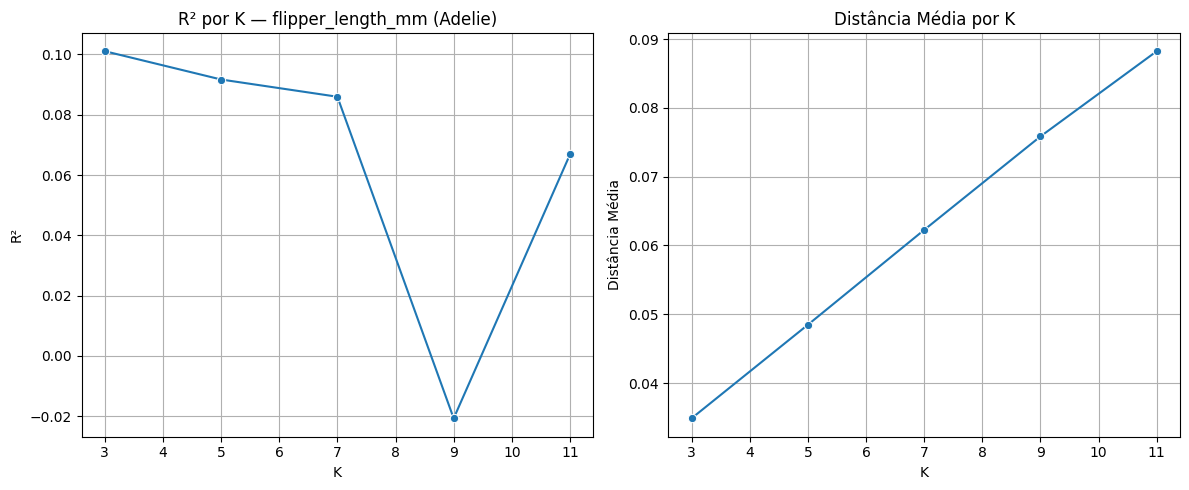

Melhor K: 3 | R²: 0.101


In [23]:
treino_fl = adelieDFnorm[adelieDFnorm['flipper_length_mm'].notna()]
prever_fl = adelieDFnorm[adelieDFnorm['flipper_length_mm'].isna()].copy()

X_train = treino_fl[['body_mass_g', 'bill_length_mm']]
y_train = treino_fl['flipper_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — flipper_length_mm (Adelie)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_fl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_fl.fit(X_train, y_train)
prever_fl['flipper_length_mm'] = knn_fl.predict(prever_fl[['body_mass_g', 'bill_length_mm']])
adelieDFnorm.update(prever_fl)

**body_mass_g (Adelie):** a relação é igual à anterior — nadadeira e comprimento de bico
refletem o tamanho geral do pinguim. Usamos flipper_length_mm e bill_length_mm.

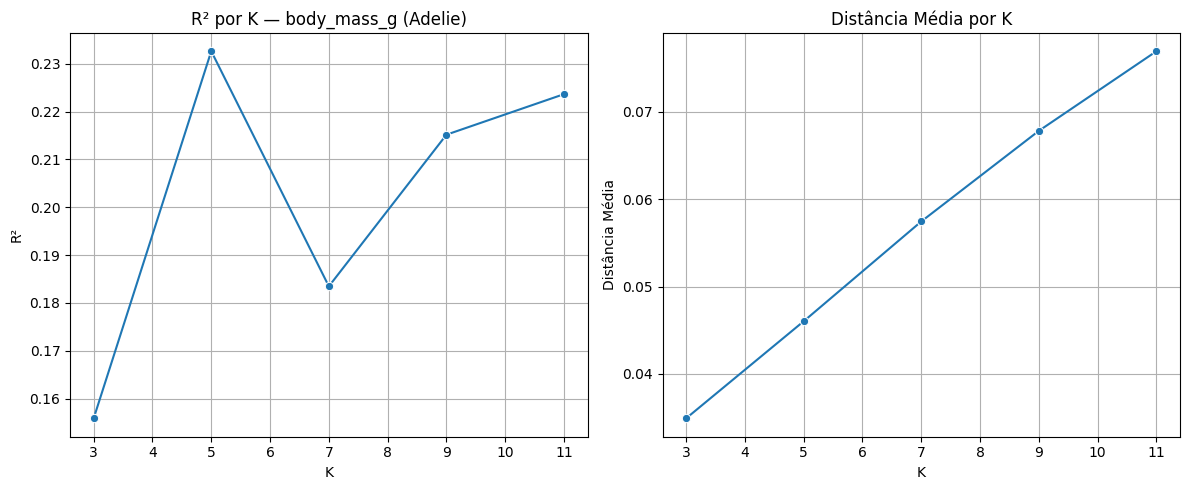

Melhor K: 5 | R²: 0.233


In [24]:
treino_bm = adelieDFnorm[adelieDFnorm['body_mass_g'].notna()]
prever_bm = adelieDFnorm[adelieDFnorm['body_mass_g'].isna()].copy()

X_train = treino_bm[['flipper_length_mm', 'bill_length_mm']]
y_train = treino_bm['body_mass_g']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — body_mass_g (Adelie)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bm = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bm.fit(X_train, y_train)
prever_bm['body_mass_g'] = knn_bm.predict(prever_bm[['flipper_length_mm', 'bill_length_mm']])
adelieDFnorm.update(prever_bm)

**bill_length_mm (Adelie):** o comprimento do bico cresce com o tamanho geral do animal
(massa corporal) e tem relação com a profundidade do bico dentro da mesma espécie.
Usamos body_mass_g e bill_depth_mm.

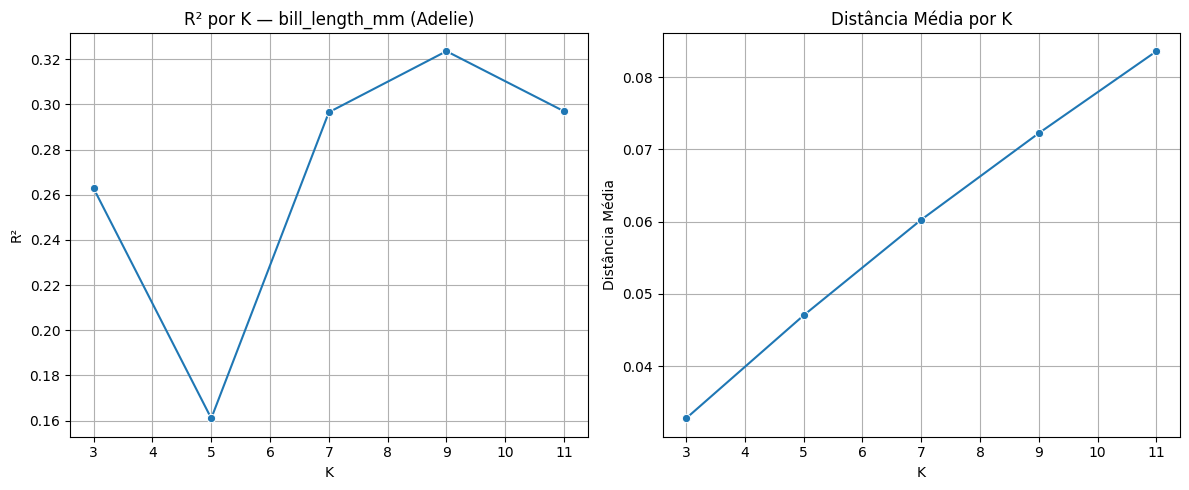

Melhor K: 9 | R²: 0.324


In [25]:
treino_bl = adelieDFnorm[adelieDFnorm['bill_length_mm'].notna()]
prever_bl = adelieDFnorm[adelieDFnorm['bill_length_mm'].isna()].copy()

X_train = treino_bl[['body_mass_g', 'bill_depth_mm']]
y_train = treino_bl['bill_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_length_mm (Adelie)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bl.fit(X_train, y_train)
prever_bl['bill_length_mm'] = knn_bl.predict(prever_bl[['body_mass_g', 'bill_depth_mm']])
adelieDFnorm.update(prever_bl)

**bill_depth_mm (Adelie):** dentro da mesma espécie, a profundidade do bico tem relação
direta com o comprimento do bico — pinguins com bico mais longo tendem a ter bico mais
alto também. Usamos bill_length_mm e flipper_length_mm.

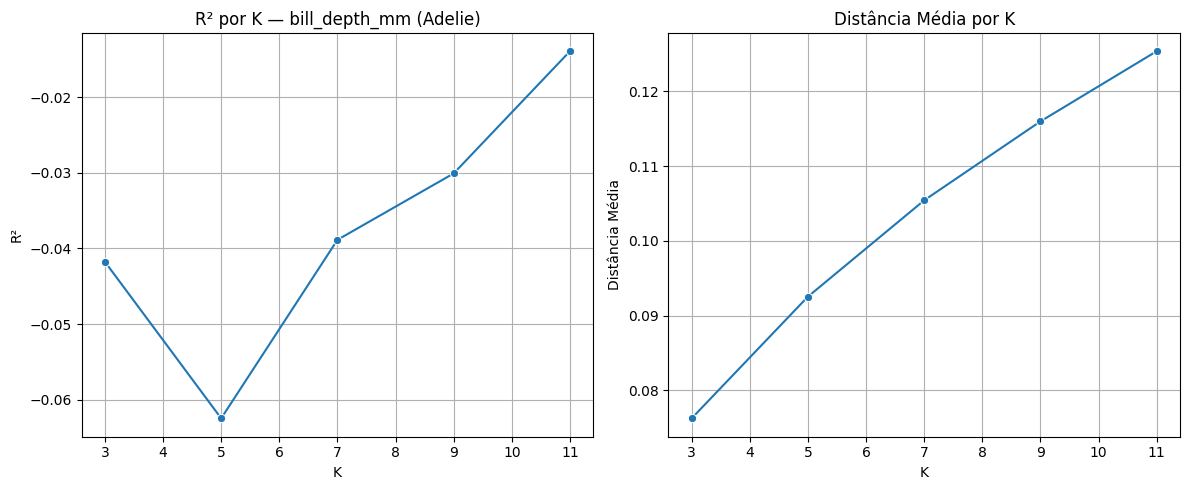

Melhor K: 11 | R²: -0.014

Devido ao R2 extremamente baixo, os valores de bill depth não serão imputado por KNN


In [26]:
treino_bd = adelieDFnorm[adelieDFnorm['bill_depth_mm'].notna()]
prever_bd = adelieDFnorm[adelieDFnorm['bill_depth_mm'].isna()].copy()

X_train = treino_bd[['bill_length_mm', 'flipper_length_mm']]
y_train = treino_bd['bill_depth_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_depth_mm (Adelie)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

print("\nDevido ao R2 extremamente baixo, os valores de bill depth não serão imputado por KNN")

Após imputar todos os atributos no espaço normalizado, revertemos com inverse_transform
para restaurar os valores na escala original e atualizamos o dataframe principal.

In [27]:
adelieFinalArray = scaler.inverse_transform(adelieDFnorm[cols_numericas])
adelieFinal = pd.DataFrame(adelieFinalArray, columns=cols_numericas, index=penguinsAdelie.index)
penguins.update(adelieFinal)

display(penguins.isna().sum())

,0
species,0
island,0
bill_length_mm,56
bill_depth_mm,93
flipper_length_mm,50
body_mass_g,58
sex,102


### Chinstrap

**Normalização dos Dados**

In [28]:
penguinsChinstrap = penguins[penguins["species"] == "Chinstrap"].copy()

scalerChin = MinMaxScaler()
scalerChin.fit(penguinsChinstrap[cols_numericas].dropna())

chinstrapNorm = scalerChin.transform(penguinsChinstrap[cols_numericas])
chinstrapDFnorm = pd.DataFrame(chinstrapNorm, columns=cols_numericas, index=penguinsChinstrap.index)

chinstrapLimpo = penguinsChinstrap[penguinsChinstrap[cols_numericas].notna().all(axis=1)]
print(f"Linhas completas disponíveis (Chinstrap): {len(chinstrapLimpo)}")
print()
print("Matriz de correlação (Chinstrap — dados completos):")
display(chinstrapLimpo[cols_numericas].corr().round(3))

Linhas completas disponíveis (Chinstrap): 18

Matriz de correlação (Chinstrap — dados completos):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.813,0.710,0.811
bill_depth_mm,0.813,1.000,0.687,0.858
flipper_length_mm,0.710,0.687,1.000,0.876
body_mass_g,0.811,0.858,0.876,1.000


**flipper_length_mm (Chinstrap):**

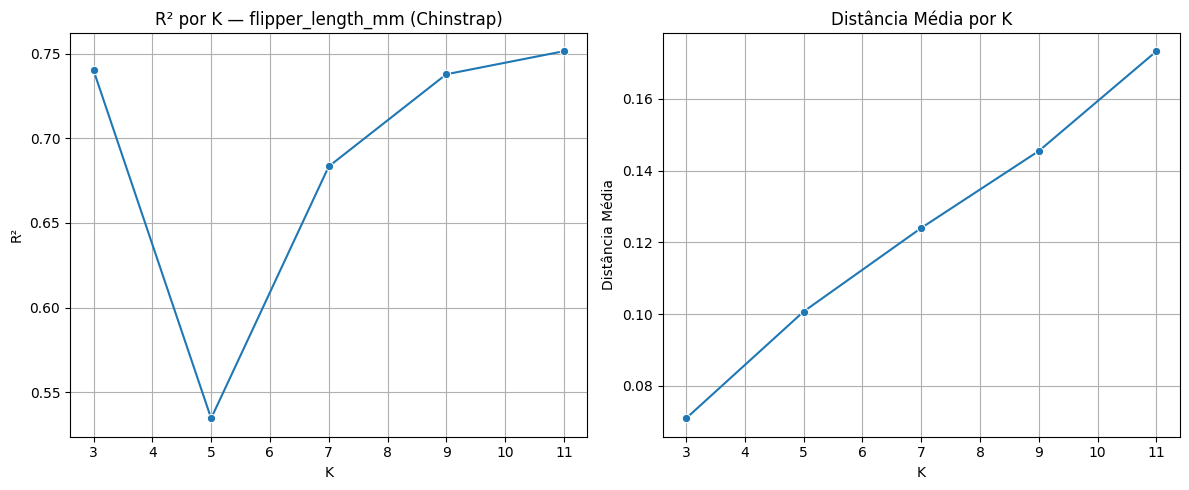

Melhor K: 11 | R²: 0.752


In [29]:
treino_fl = chinstrapDFnorm[chinstrapDFnorm['flipper_length_mm'].notna()]
prever_fl = chinstrapDFnorm[chinstrapDFnorm['flipper_length_mm'].isna()].copy()

X_train = treino_fl[['body_mass_g', 'bill_length_mm']]
y_train = treino_fl['flipper_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — flipper_length_mm (Chinstrap)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_fl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_fl.fit(X_train, y_train)
prever_fl['flipper_length_mm'] = knn_fl.predict(prever_fl[['body_mass_g', 'bill_length_mm']])
chinstrapDFnorm.update(prever_fl)

**body_mass_g (Chinstrap)**

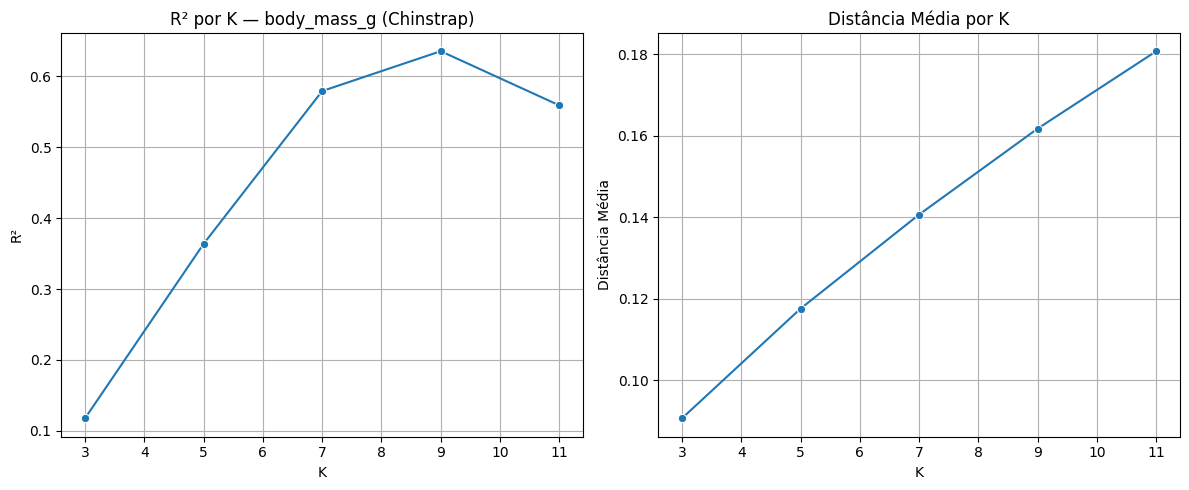

Melhor K: 9 | R²: 0.636


In [30]:
treino_bm = chinstrapDFnorm[chinstrapDFnorm['body_mass_g'].notna()]
prever_bm = chinstrapDFnorm[chinstrapDFnorm['body_mass_g'].isna()].copy()

X_train = treino_bm[['flipper_length_mm', 'bill_length_mm']]
y_train = treino_bm['body_mass_g']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — body_mass_g (Chinstrap)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bm = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bm.fit(X_train, y_train)
prever_bm['body_mass_g'] = knn_bm.predict(prever_bm[['flipper_length_mm', 'bill_length_mm']])
chinstrapDFnorm.update(prever_bm)

**bill_length_mm (Chinstrap)**

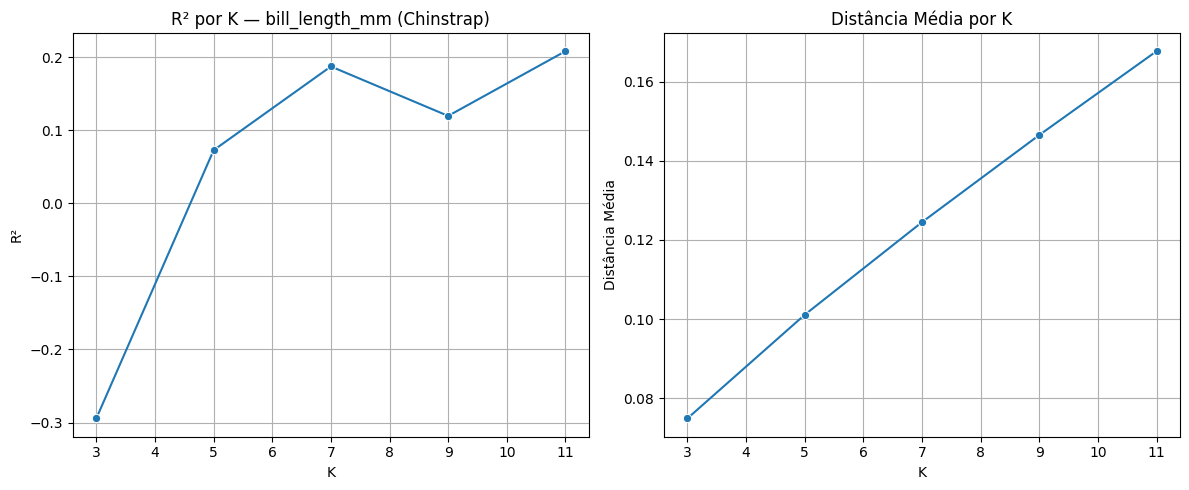

Melhor K: 11 | R²: 0.208


In [31]:
treino_bl = chinstrapDFnorm[chinstrapDFnorm['bill_length_mm'].notna()]
prever_bl = chinstrapDFnorm[chinstrapDFnorm['bill_length_mm'].isna()].copy()

X_train = treino_bl[['body_mass_g', 'bill_depth_mm']]
y_train = treino_bl['bill_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_length_mm (Chinstrap)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bl.fit(X_train, y_train)
prever_bl['bill_length_mm'] = knn_bl.predict(prever_bl[['body_mass_g', 'bill_depth_mm']])
chinstrapDFnorm.update(prever_bl)

**bill_depth_mm (Chinstrap)**

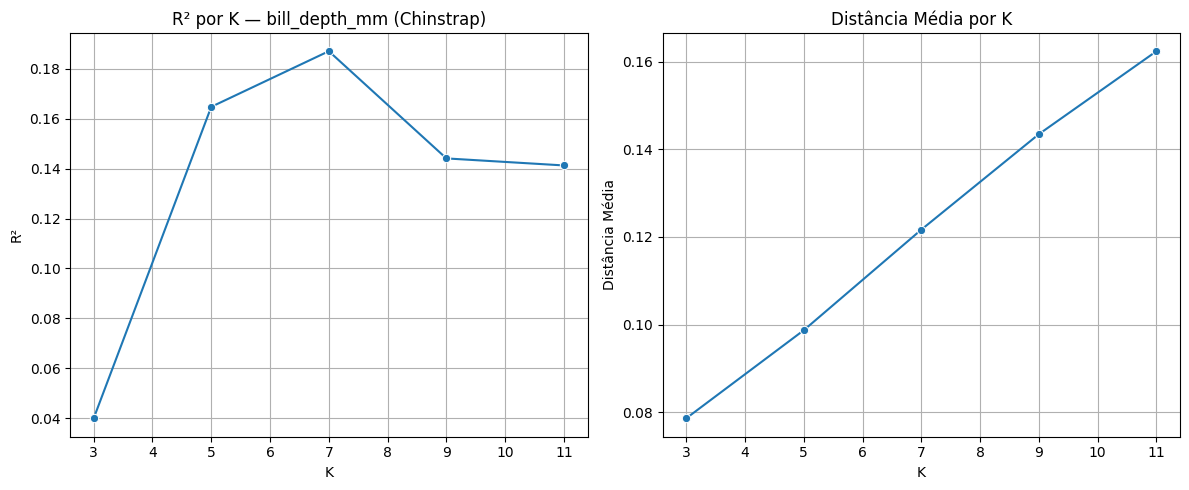

Melhor K: 7 | R²: 0.187


In [32]:
treino_bd = chinstrapDFnorm[chinstrapDFnorm['bill_depth_mm'].notna()]
prever_bd = chinstrapDFnorm[chinstrapDFnorm['bill_depth_mm'].isna()].copy()

X_train = treino_bd[['bill_length_mm', 'flipper_length_mm']]
y_train = treino_bd['bill_depth_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_depth_mm (Chinstrap)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bd = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bd.fit(X_train, y_train)
prever_bd['bill_depth_mm'] = knn_bd.predict(prever_bd[['bill_length_mm', 'flipper_length_mm']])
chinstrapDFnorm.update(prever_bd)

**Restauração dos Valores na Escala Original**

In [33]:
chinstrapFinalArray = scalerChin.inverse_transform(chinstrapDFnorm[cols_numericas])
chinstrapFinal = pd.DataFrame(chinstrapFinalArray, columns=cols_numericas, index=penguinsChinstrap.index)
penguins.update(chinstrapFinal)

display(penguins.isna().sum())

,0
species,0
island,0
bill_length_mm,40
bill_depth_mm,75
flipper_length_mm,34
body_mass_g,41
sex,102


### Gentoo

**Normalização dos Dados**

In [34]:
penguinsGentoo = penguins[penguins["species"] == "Gentoo"].copy()

scalerGent = MinMaxScaler()
scalerGent.fit(penguinsGentoo[cols_numericas].dropna())

gentooNorm = scalerGent.transform(penguinsGentoo[cols_numericas])
gentooDFnorm = pd.DataFrame(gentooNorm, columns=cols_numericas, index=penguinsGentoo.index)

gentooLimpo = penguinsGentoo[penguinsGentoo[cols_numericas].notna().all(axis=1)]
print(f"Linhas completas disponíveis (Gentoo): {len(gentooLimpo)}")
print()
print("Matriz de correlação (Gentoo — dados completos):")
display(gentooLimpo[cols_numericas].corr().round(3))

Linhas completas disponíveis (Gentoo): 25

Matriz de correlação (Gentoo — dados completos):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,0.564,0.734,0.636
bill_depth_mm,0.564,1.000,0.738,0.633
flipper_length_mm,0.734,0.738,1.000,0.745
body_mass_g,0.636,0.633,0.745,1.000


**flipper_length_mm (Gentoo)**

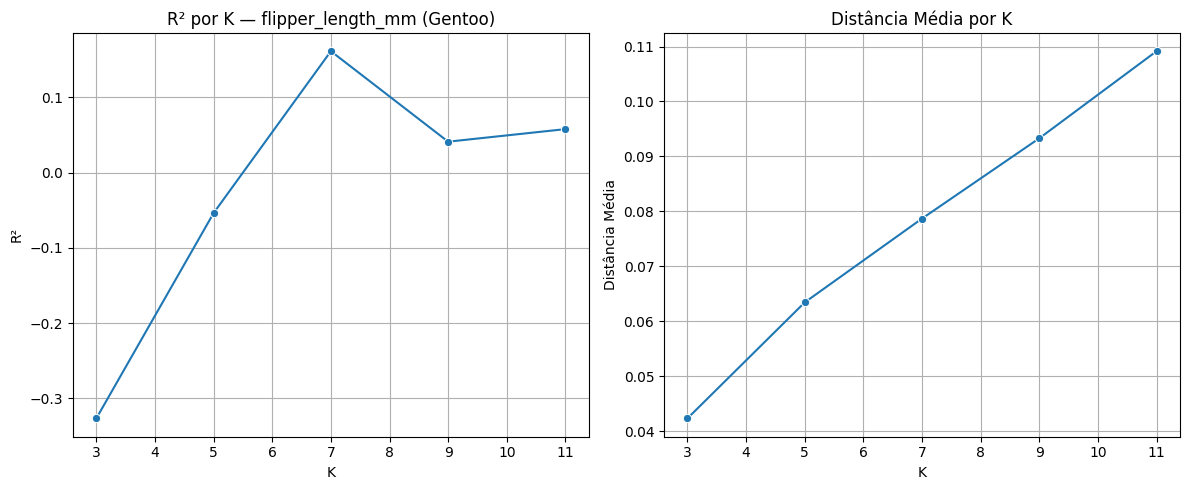

Melhor K: 7 | R²: 0.162


In [35]:
treino_fl = gentooDFnorm[gentooDFnorm['flipper_length_mm'].notna()]
prever_fl = gentooDFnorm[gentooDFnorm['flipper_length_mm'].isna()].copy()

X_train = treino_fl[['body_mass_g', 'bill_length_mm']]
y_train = treino_fl['flipper_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — flipper_length_mm (Gentoo)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_fl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_fl.fit(X_train, y_train)
prever_fl['flipper_length_mm'] = knn_fl.predict(prever_fl[['body_mass_g', 'bill_length_mm']])
gentooDFnorm.update(prever_fl)

**body_mass_g (Gentoo)**

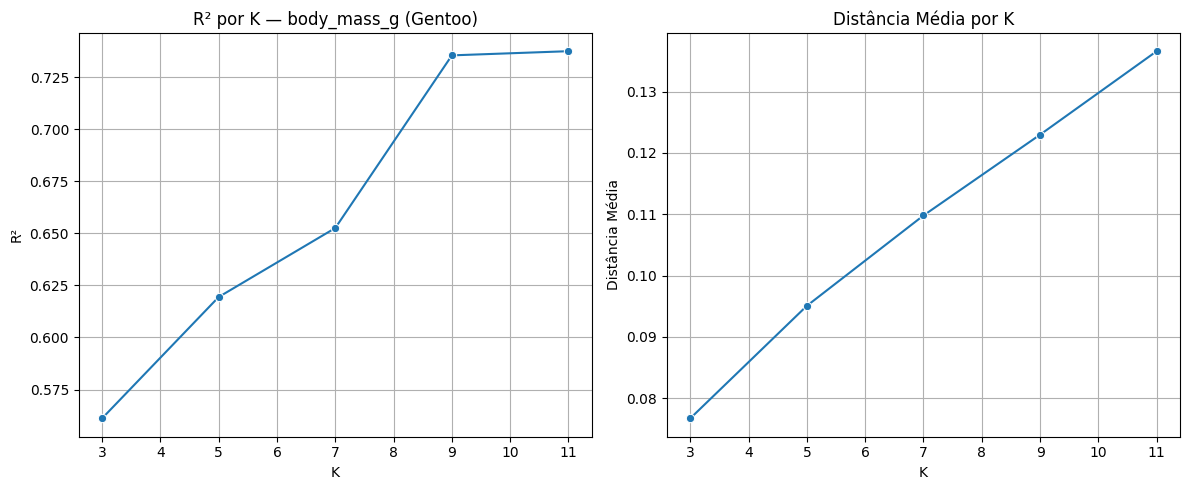

Melhor K: 11 | R²: 0.737


In [36]:
treino_bm = gentooDFnorm[gentooDFnorm['body_mass_g'].notna()]
prever_bm = gentooDFnorm[gentooDFnorm['body_mass_g'].isna()].copy()

X_train = treino_bm[['flipper_length_mm', 'bill_length_mm']]
y_train = treino_bm['body_mass_g']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — body_mass_g (Gentoo)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bm = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bm.fit(X_train, y_train)
prever_bm['body_mass_g'] = knn_bm.predict(prever_bm[['flipper_length_mm', 'bill_length_mm']])
gentooDFnorm.update(prever_bm)

**bill_length_mm (Gentoo)**

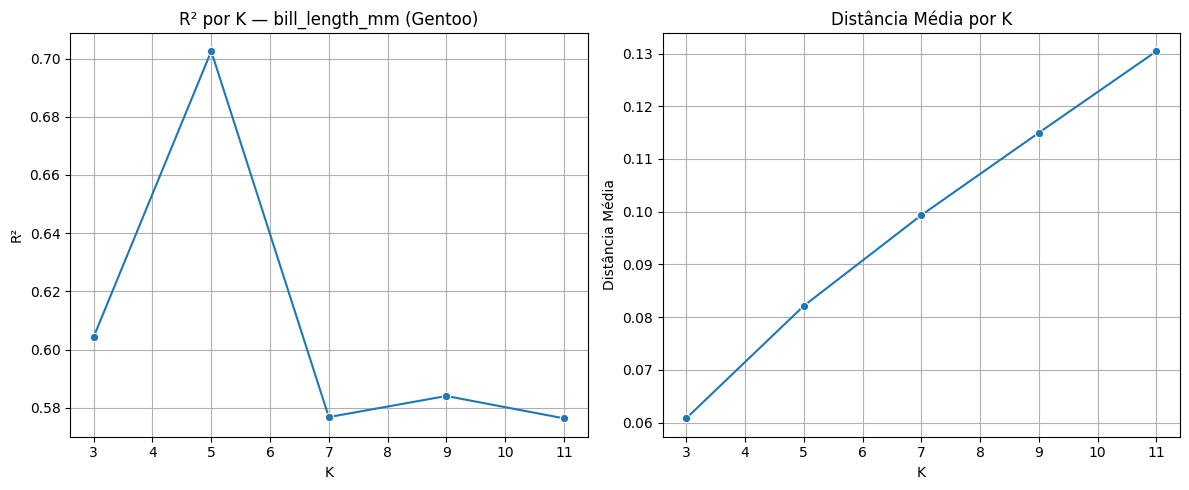

Melhor K: 5 | R²: 0.703


In [37]:
treino_bl = gentooDFnorm[gentooDFnorm['bill_length_mm'].notna()]
prever_bl = gentooDFnorm[gentooDFnorm['bill_length_mm'].isna()].copy()

X_train = treino_bl[['body_mass_g', 'bill_depth_mm']]
y_train = treino_bl['bill_length_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_length_mm (Gentoo)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bl = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bl.fit(X_train, y_train)
prever_bl['bill_length_mm'] = knn_bl.predict(prever_bl[['body_mass_g', 'bill_depth_mm']])
gentooDFnorm.update(prever_bl)

**bill_depth_mm (Gentoo)**

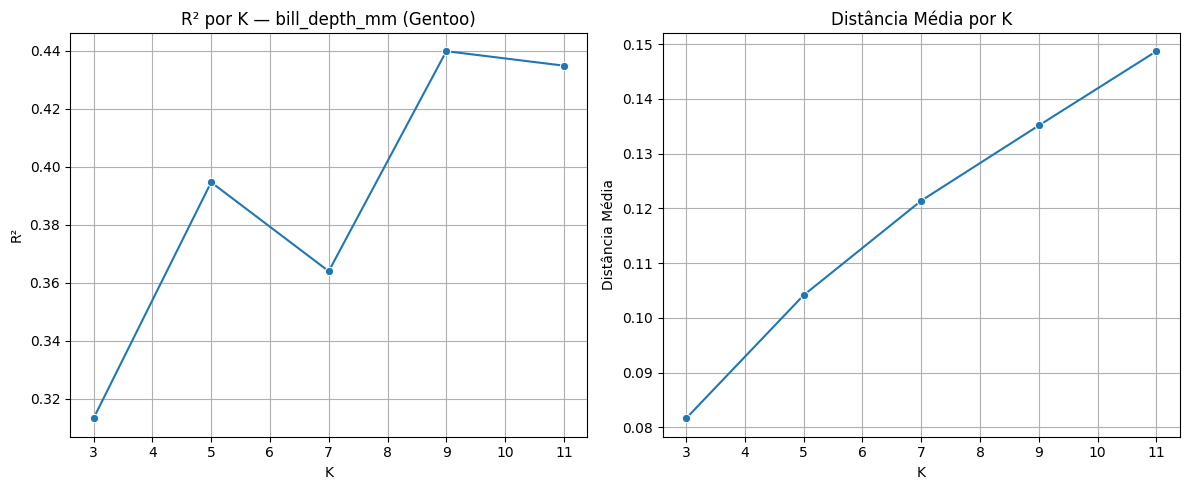

Melhor K: 9 | R²: 0.440


In [38]:
treino_bd = gentooDFnorm[gentooDFnorm['bill_depth_mm'].notna()]
prever_bd = gentooDFnorm[gentooDFnorm['bill_depth_mm'].isna()].copy()

X_train = treino_bd[['bill_length_mm', 'flipper_length_mm']]
y_train = treino_bd['bill_depth_mm']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

acertos    = dict()
dist_medias = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='nan_euclidean')
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k]     = knn.score(X_val_limpo, y_val_limpo)
    dist_medias[k] = np.array(knn.kneighbors(X_val_limpo)[0]).mean()

acertosX = list(acertos.keys())
acertosY = list(acertos.values())
mediasX  = list(dist_medias.keys())
mediasY  = list(dist_medias.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=acertosX, y=acertosY, ax=axes[0], marker='o')
axes[0].set_title('R² por K — bill_depth_mm (Gentoo)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('R²')
axes[0].grid(True)
sns.lineplot(x=mediasX, y=mediasY, ax=axes[1], marker='o')
axes[1].set_title('Distância Média por K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Distância Média')
axes[1].grid(True)
plt.tight_layout()
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | R²: {acertos[melhor_k]:.3f}")

knn_bd = KNeighborsRegressor(n_neighbors=melhor_k, weights='uniform', metric='nan_euclidean')
knn_bd.fit(X_train, y_train)
prever_bd['bill_depth_mm'] = knn_bd.predict(prever_bd[['bill_length_mm', 'flipper_length_mm']])
gentooDFnorm.update(prever_bd)

**Restauração dos Valores na Escala Original**

In [39]:
gentooFinalArray = scalerGent.inverse_transform(gentooDFnorm[cols_numericas])
gentooFinal = pd.DataFrame(gentooFinalArray, columns=cols_numericas, index=penguinsGentoo.index)
penguins.update(gentooFinal)

display(penguins.isna().sum())

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,43
flipper_length_mm,0
body_mass_g,0
sex,102


## 4. Imputação de Sexo

O sexo é imputado por KNN Classifier separadamente por espécie. Pinguins apresentam
dimorfismo sexual — machos são maiores — mas a escala de tamanho difere muito entre
espécies: um macho Adelie pode ter massa similar a uma fêmea Gentoo. Misturar espécies
prejudicaria o cálculo de distância do KNN.

### Adelie

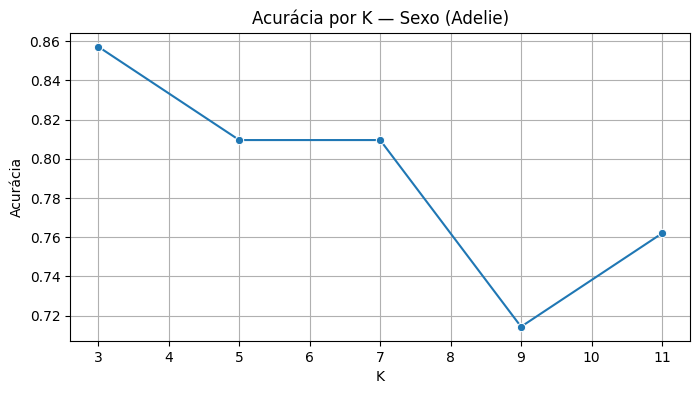

Melhor K: 3 | Acurácia: 0.857


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,43
flipper_length_mm,0
body_mass_g,0
sex,0


In [40]:
penguinsAdelie = penguins[penguins["species"] == "Adelie"].copy()

scalerSex = MinMaxScaler()
adelieSexNorm = pd.DataFrame(
    scalerSex.fit_transform(penguinsAdelie[cols_numericas]),
    columns=cols_numericas,
    index=penguinsAdelie.index
)

treino_sex = adelieSexNorm[penguinsAdelie["sex"].notna()]
prever_sex  = adelieSexNorm[penguinsAdelie["sex"].isna()].copy()
y_treino    = penguinsAdelie.loc[penguinsAdelie["sex"].notna(), "sex"]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    treino_sex, y_treino, test_size=0.3, random_state=42
)

acertos = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="nan_euclidean")
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k] = knn.score(X_val_limpo, y_val_limpo)

acertosX = list(acertos.keys())
acertosY = list(acertos.values())

plt.figure(figsize=(8, 4))
sns.lineplot(x=acertosX, y=acertosY, marker="o")
plt.title("Acurácia por K — Sexo (Adelie)")
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | Acurácia: {acertos[melhor_k]:.3f}")

knn_sex = KNeighborsClassifier(n_neighbors=melhor_k, metric="nan_euclidean")
knn_sex.fit(treino_sex, y_treino)

filtro = (penguins["species"] == "Adelie") & (penguins["sex"].isna())
subset = penguins[filtro].copy()
subset["sex"] = knn_sex.predict(prever_sex)
penguins.update(subset)

display(penguins[penguins["species"] == "Adelie"].isna().sum())

### Chinstrap

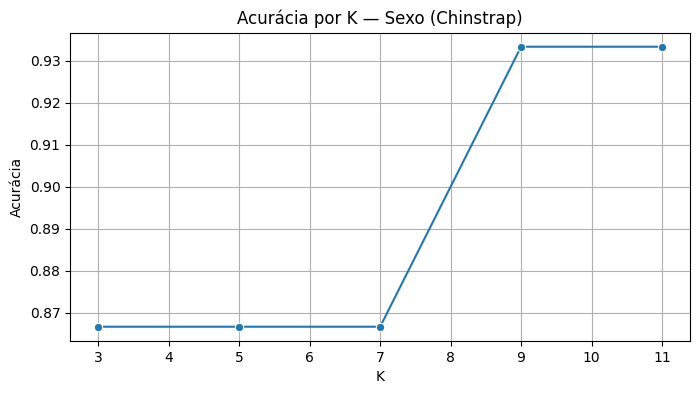

Melhor K: 9 | Acurácia: 0.933


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [41]:
penguinsChinstrap = penguins[penguins["species"] == "Chinstrap"].copy()

scalerSex = MinMaxScaler()
chinstrapSexNorm = pd.DataFrame(
    scalerSex.fit_transform(penguinsChinstrap[cols_numericas]),
    columns=cols_numericas,
    index=penguinsChinstrap.index
)

treino_sex = chinstrapSexNorm[penguinsChinstrap["sex"].notna()]
prever_sex  = chinstrapSexNorm[penguinsChinstrap["sex"].isna()].copy()
y_treino    = penguinsChinstrap.loc[penguinsChinstrap["sex"].notna(), "sex"]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    treino_sex, y_treino, test_size=0.3, random_state=42
)

acertos = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="nan_euclidean")
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k] = knn.score(X_val_limpo, y_val_limpo)

acertosX = list(acertos.keys())
acertosY = list(acertos.values())

plt.figure(figsize=(8, 4))
sns.lineplot(x=acertosX, y=acertosY, marker="o")
plt.title("Acurácia por K — Sexo (Chinstrap)")
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | Acurácia: {acertos[melhor_k]:.3f}")

knn_sex = KNeighborsClassifier(n_neighbors=melhor_k, metric="nan_euclidean")
knn_sex.fit(treino_sex, y_treino)

filtro = (penguins["species"] == "Chinstrap") & (penguins["sex"].isna())
subset = penguins[filtro].copy()
subset["sex"] = knn_sex.predict(prever_sex)
penguins.update(subset)

display(penguins[penguins["species"] == "Chinstrap"].isna().sum())

### Gentoo

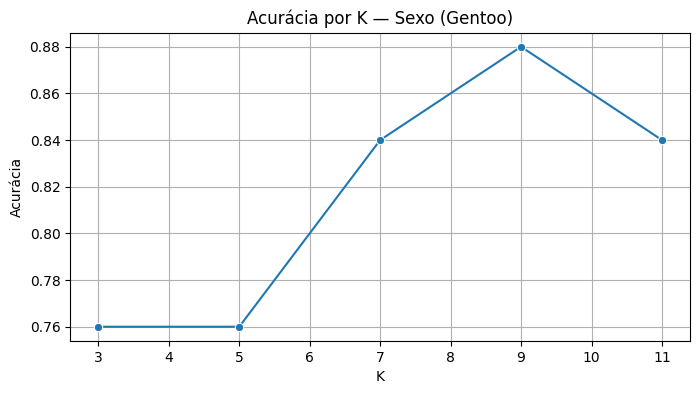

Melhor K: 9 | Acurácia: 0.880


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [42]:
penguinsGentoo = penguins[penguins["species"] == "Gentoo"].copy()

scalerSex = MinMaxScaler()
gentooSexNorm = pd.DataFrame(
    scalerSex.fit_transform(penguinsGentoo[cols_numericas]),
    columns=cols_numericas,
    index=penguinsGentoo.index
)

treino_sex = gentooSexNorm[penguinsGentoo["sex"].notna()]
prever_sex  = gentooSexNorm[penguinsGentoo["sex"].isna()].copy()
y_treino    = penguinsGentoo.loc[penguinsGentoo["sex"].notna(), "sex"]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    treino_sex, y_treino, test_size=0.3, random_state=42
)

acertos = dict()

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="nan_euclidean")
    knn.fit(X_train_split, y_train_split)

    mask_limpo = X_test_split.notna().all(axis=1)
    X_val_limpo = X_test_split[mask_limpo]
    y_val_limpo = y_test_split[mask_limpo]

    acertos[k] = knn.score(X_val_limpo, y_val_limpo)

acertosX = list(acertos.keys())
acertosY = list(acertos.values())

plt.figure(figsize=(8, 4))
sns.lineplot(x=acertosX, y=acertosY, marker="o")
plt.title("Acurácia por K — Sexo (Gentoo)")
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

melhor_k = max(acertos, key=acertos.get)
print(f"Melhor K: {melhor_k} | Acurácia: {acertos[melhor_k]:.3f}")

knn_sex = KNeighborsClassifier(n_neighbors=melhor_k, metric="nan_euclidean")
knn_sex.fit(treino_sex, y_treino)

filtro = (penguins["species"] == "Gentoo") & (penguins["sex"].isna())
subset = penguins[filtro].copy()
subset["sex"] = knn_sex.predict(prever_sex)
penguins.update(subset)

display(penguins[penguins["species"] == "Gentoo"].isna().sum())

### Imputação final pela mediana da espécie

Os valores restantes de `bill_depth_mm` nos Adelie serão preenchidos pela mediana da própria espécie, pois o R² máximo desse atributo ao usar KNN foi negativo.

In [43]:
print("Adelie")
print(penguins[penguins["species"] == "Adelie"].isna().sum())

print("\nChinstrap")
print(penguins[penguins["species"] == "Chinstrap"].isna().sum())

print("\nGentoo")
print(penguins[penguins["species"] == "Gentoo"].isna().sum())

Adelie
species               0
island                0
bill_length_mm        0
bill_depth_mm        43
flipper_length_mm     0
body_mass_g           0
sex                   0
dtype: int64

Chinstrap
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Gentoo
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [44]:
mediana_bd_adelie = penguins.loc[penguins["species"] == "Adelie", "bill_depth_mm"].median()
penguins.loc[(penguins["species"] == "Adelie") & (penguins["bill_depth_mm"].isna()), "bill_depth_mm"] = mediana_bd_adelie

display(penguins.isna().sum())

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


### Gráficos Finais

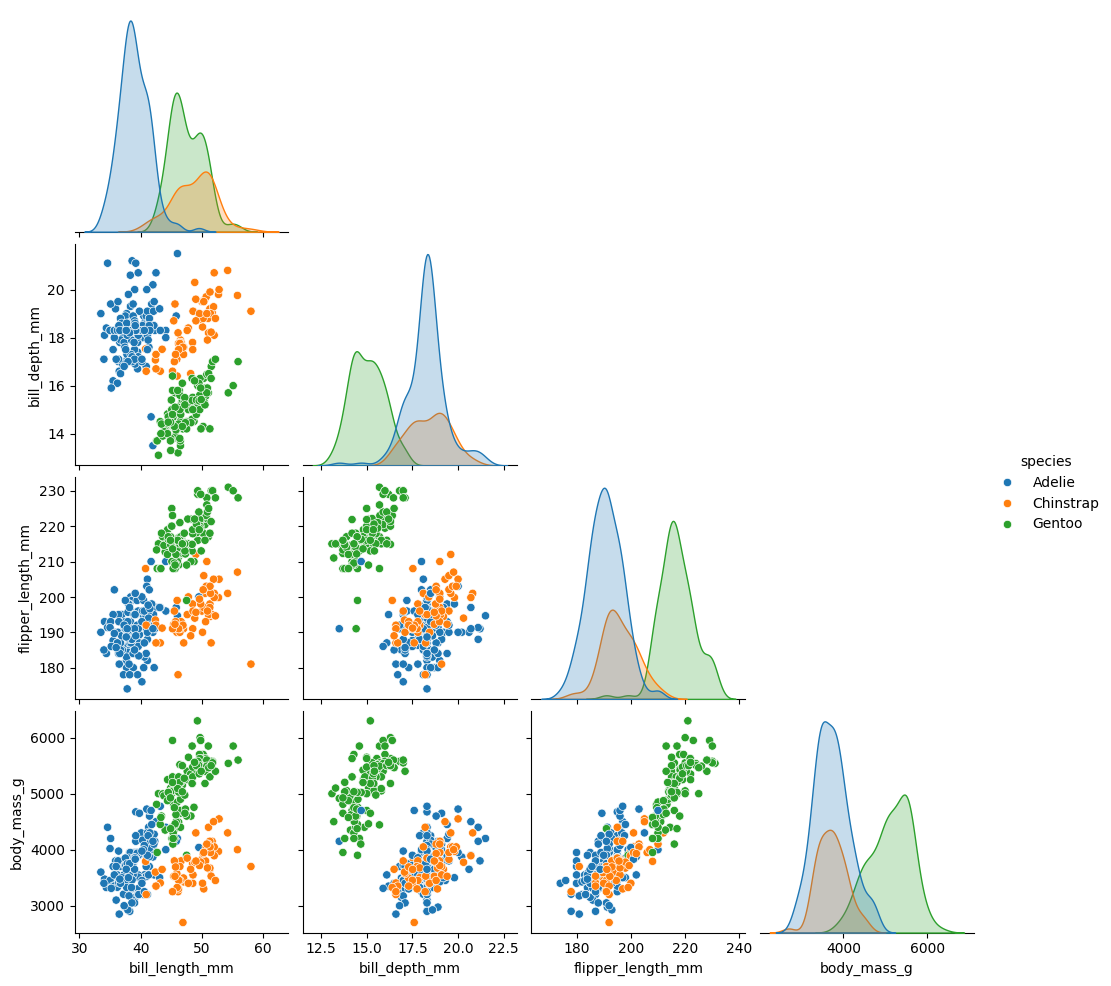

In [45]:
sns.pairplot(penguins, corner=True, hue="species")
plt.show()

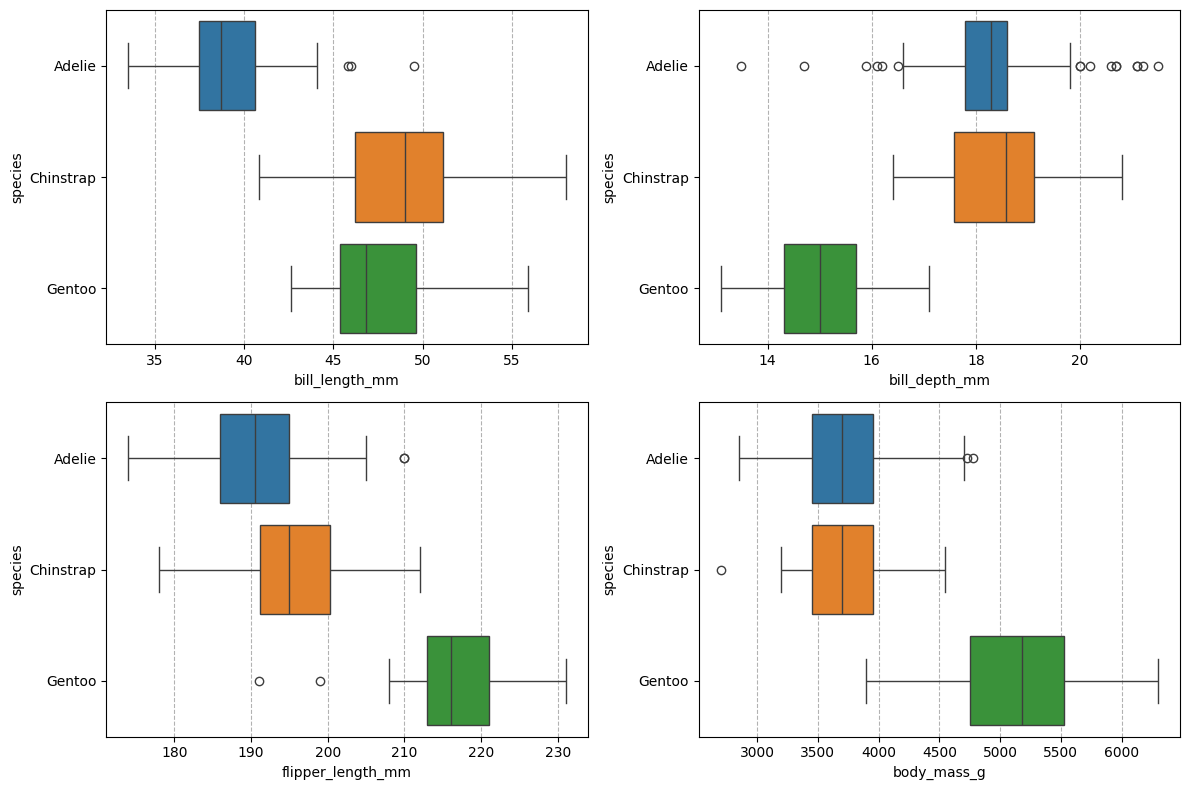

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(penguins, x="bill_length_mm", y="species", hue="species", ax=axes[0, 0])
axes[0, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="bill_depth_mm", y="species", hue="species", ax=axes[0, 1])
axes[0, 1].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="flipper_length_mm", y="species", hue="species", ax=axes[1, 0])
axes[1, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.boxplot(penguins, x="body_mass_g", y="species", hue="species", ax=axes[1, 1])
axes[1, 1].grid(axis='x', linestyle="--", alpha=0.3, color="Black")

plt.tight_layout()
plt.show()

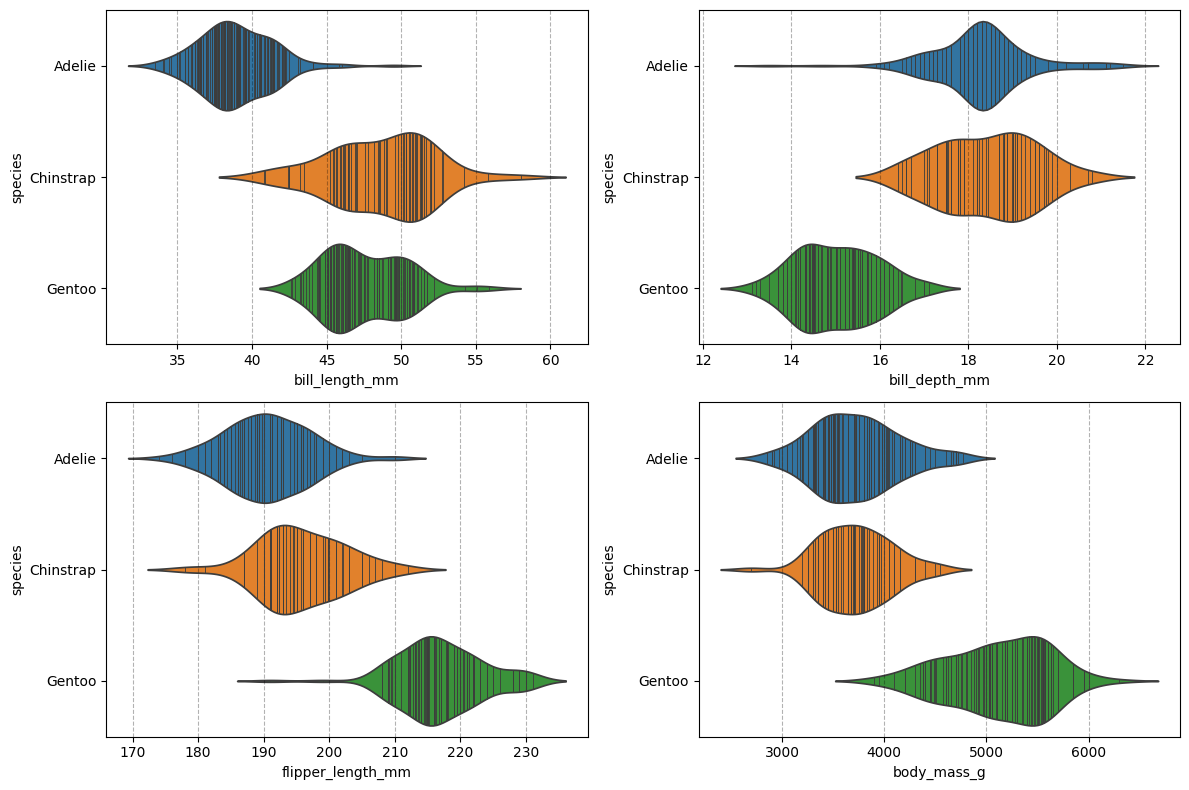

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(penguins, x="bill_length_mm", y="species", hue="species", inner='stick', ax=axes[0, 0])
axes[0, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="bill_depth_mm", y="species", hue="species", inner='stick', ax=axes[0, 1])
axes[0, 1].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="flipper_length_mm", y="species", hue="species", inner='stick', ax=axes[1, 0])
axes[1, 0].grid(axis='x',linestyle="--", alpha=0.3, color="Black")

sns.violinplot(penguins, x="body_mass_g", y="species", hue="species", inner='stick', ax=axes[1, 1])
axes[1, 1].grid(axis='x', linestyle="--", alpha=0.3, color="Black")

plt.tight_layout()
plt.show()

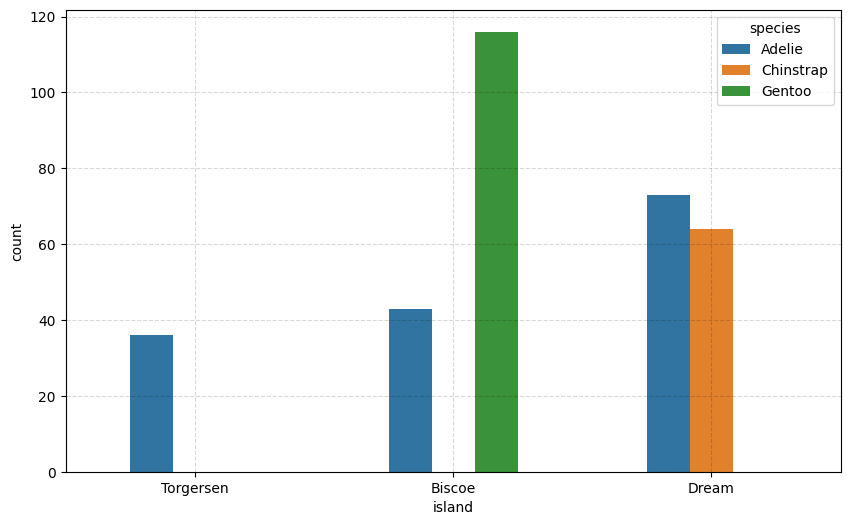

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(penguins, x="island", hue="species", width=0.5)
plt.grid(linestyle="--", color="Black", alpha=0.15)
plt.show()

### Criando novo csv

In [49]:
penguins[cols_numericas] = penguins[cols_numericas].round(2)

In [50]:
penguins.to_csv("penguins_imputado.csv", index=False)